In [1]:
!pip install -q xgboost imbalanced-learn shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

RANDOM_STATE = 42

In [3]:
# Option B: If you already have a single CSV (e.g. creditcard.csv)
df = pd.read_csv('/content/creditcard.csv')   # <-- PUT YOUR PATH HERE
target_col = 'Class'   # for the classic Kaggle credit card dataset
# target_col = 'isFraud'   # for IEEE-CIS

Fraud rate: 0.1727%
Fraud: 492, Non-fraud: 284315


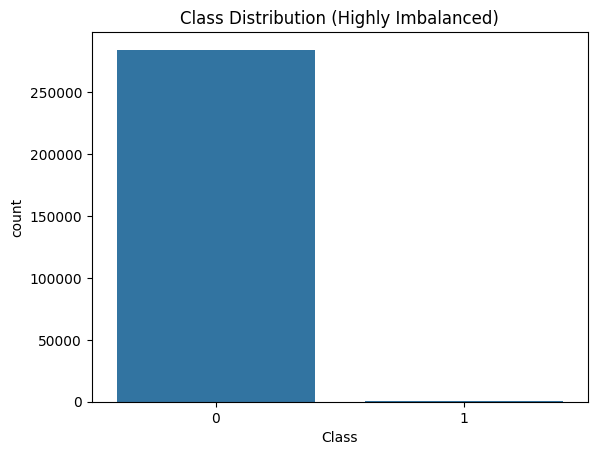

In [4]:
fraud_rate = df[target_col].mean()
print(f"Fraud rate: {fraud_rate:.4%}")
print(f"Fraud: {df[target_col].sum()}, Non-fraud: {(df[target_col]==0).sum()}")

sns.countplot(x=target_col, data=df)
plt.title("Class Distribution (Highly Imbalanced)")
plt.show()

In [5]:
# Drop ID column, separate target
drop_cols = ['TransactionID']
y = df[target_col]
X = df.drop(columns=[target_col] + drop_cols, errors='ignore')

# Handle categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col] = X[col].astype(str)
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].fillna('missing'))

# Fill remaining numeric NaNs (XGBoost can handle NaN natively, but for SMOTE we need clean data)
X = X.fillna(-999)

# Drop columns that are entirely constant or >90% missing originally (optional cleanup)
nunique = X.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
X = X.drop(columns=constant_cols)

print(f"Final feature matrix shape: {X.shape}")

Final feature matrix shape: (284807, 30)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.001729245759178389
Test fraud rate: 0.0017204452090867595


In [7]:
# SMOTE is expensive on very high-dim/large data — subsample majority first if needed,
# or use sampling_strategy to only partially balance (avoids overfitting on synthetic noise)
smote = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE, k_neighbors=5)
# sampling_strategy=0.3 means minority class becomes 30% of majority count
# (fully balancing to 1.0 often over-synthesizes fraud patterns and hurts precision)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 68235}


In [8]:
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',      # PR-AUC is the right metric for imbalance, not accuracy
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-aucpr:0.52055
[50]	validation_0-aucpr:0.73008
[100]	validation_0-aucpr:0.84114
[150]	validation_0-aucpr:0.85602
[200]	validation_0-aucpr:0.86622
[250]	validation_0-aucpr:0.87328
[300]	validation_0-aucpr:0.87648
[350]	validation_0-aucpr:0.87681
[400]	validation_0-aucpr:0.87762
[450]	validation_0-aucpr:0.87848
[499]	validation_0-aucpr:0.87770


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [9]:
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

print("=== Default threshold (0.5) ===")
print(classification_report(y_test, y_pred_default, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))

=== Default threshold (0.5) ===
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997     56864
           1     0.8000    0.8571    0.8276        98

    accuracy                         0.9994     56962
   macro avg     0.8999    0.9284    0.9136     56962
weighted avg     0.9994    0.9994    0.9994     56962

ROC-AUC: 0.9825329752047133
PR-AUC (Average Precision): 0.8778528981262633


Best threshold (max F1): 0.9635
Precision: 0.9512, Recall: 0.7959, F1: 0.8667


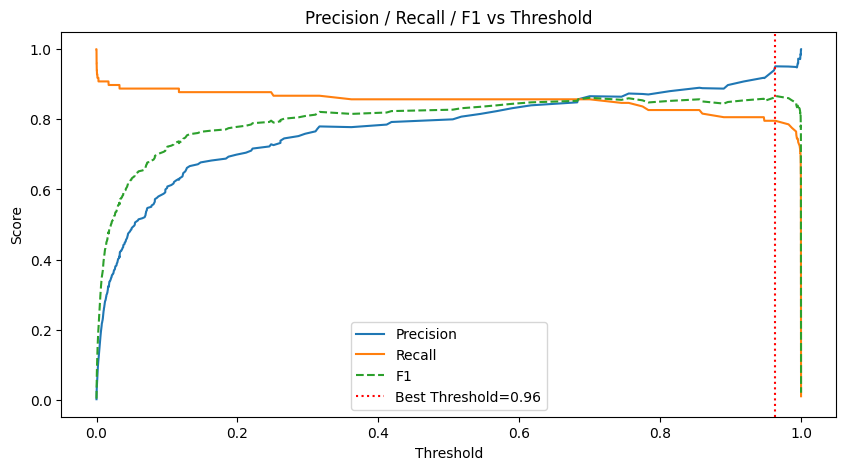

=== Tuned threshold ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9512    0.7959    0.8667        98

    accuracy                         0.9996     56962
   macro avg     0.9754    0.8979    0.9332     56962
weighted avg     0.9996    0.9996    0.9996     56962



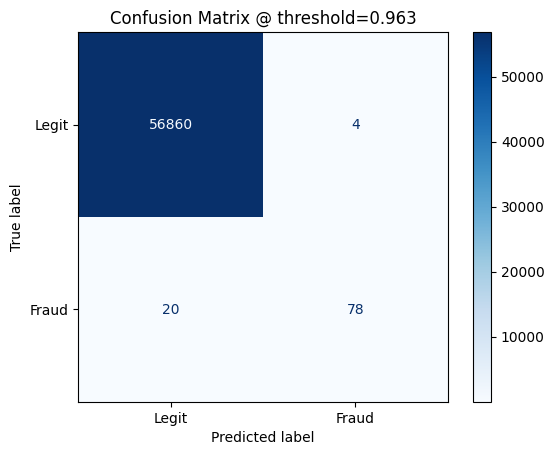

Threshold for recall>=0.9: 0.0169 (precision=0.3248, recall=0.9082)


In [12]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F1 at each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}")

# Plot precision-recall vs threshold
plt.figure(figsize=(10,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1', linestyle='--')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best Threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision / Recall / F1 vs Threshold')
plt.show()

# Apply tuned threshold
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("=== Tuned threshold ===")
print(classification_report(y_test, y_pred_tuned, digits=4))

cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']).plot(cmap='Blues')
plt.title(f"Confusion Matrix @ threshold={best_threshold:.3f}")
plt.show()

# Alternative: pick threshold for a fixed target recall (e.g. catch ≥90% of fraud)
target_recall = 0.90
valid_idx = np.where(recalls[:-1] >= target_recall)[0]
if len(valid_idx) > 0:
    chosen_idx = valid_idx[np.argmax(precisions[:-1][valid_idx])]  # max precision among those meeting recall
    recall_threshold = thresholds[chosen_idx]
    print(f"Threshold for recall>={target_recall}: {recall_threshold:.4f} "
          f"(precision={precisions[chosen_idx]:.4f}, recall={recalls[chosen_idx]:.4f})")


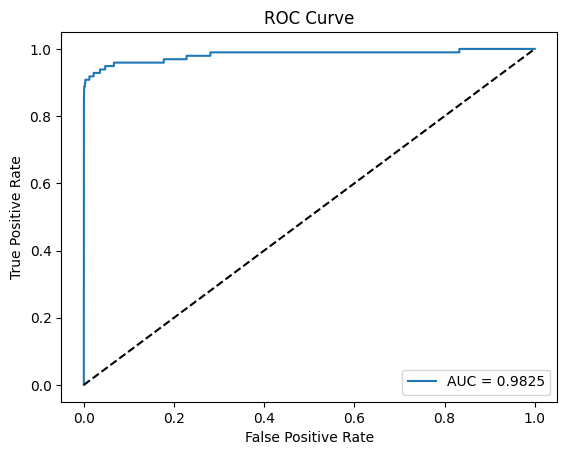

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

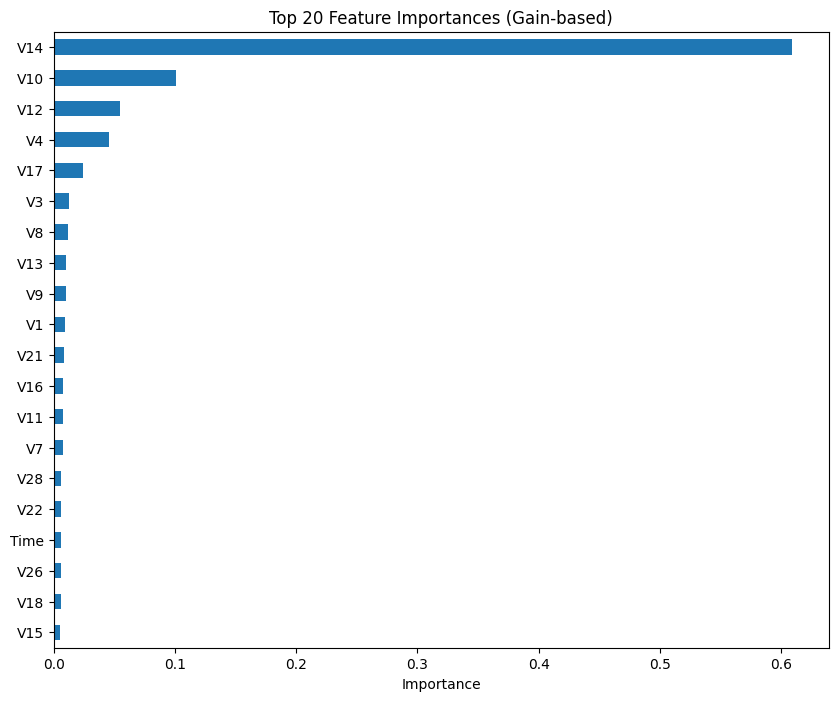

V14     0.608900
V10     0.100783
V12     0.054573
V4      0.045198
V17     0.023943
V3      0.012978
V8      0.011817
V13     0.010413
V9      0.010274
V1      0.009484
V21     0.008380
V16     0.007790
V11     0.007445
V7      0.007243
V28     0.006172
V22     0.005934
Time    0.005838
V26     0.005742
V18     0.005619
V15     0.005577
dtype: float32

Top 5 by weight: [('Time', 1178.0), ('V14', 1003.0), ('V4', 941.0), ('Amount', 701.0), ('V3', 693.0)]

Top 5 by gain: [('V14', 1869.1510009765625), ('V10', 309.3743591308594), ('V12', 167.5245361328125), ('V4', 138.74517822265625), ('V17', 73.49774169921875)]

Top 5 by cover: [('V14', 2236.3837890625), ('V4', 1718.8682861328125), ('V12', 1079.69921875), ('V10', 1037.507080078125), ('V17', 1006.76953125)]


In [16]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,8))
feat_imp.head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (Gain-based)')
plt.xlabel('Importance')
plt.show()

print(feat_imp.head(20))

# Also check 'gain' and 'cover' importance types via the booster (more informative than default 'weight')
booster = model.get_booster()
for imp_type in ['weight', 'gain', 'cover']:
    scores = booster.get_score(importance_type=imp_type)
    top5 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\nTop 5 by {imp_type}:", top5)

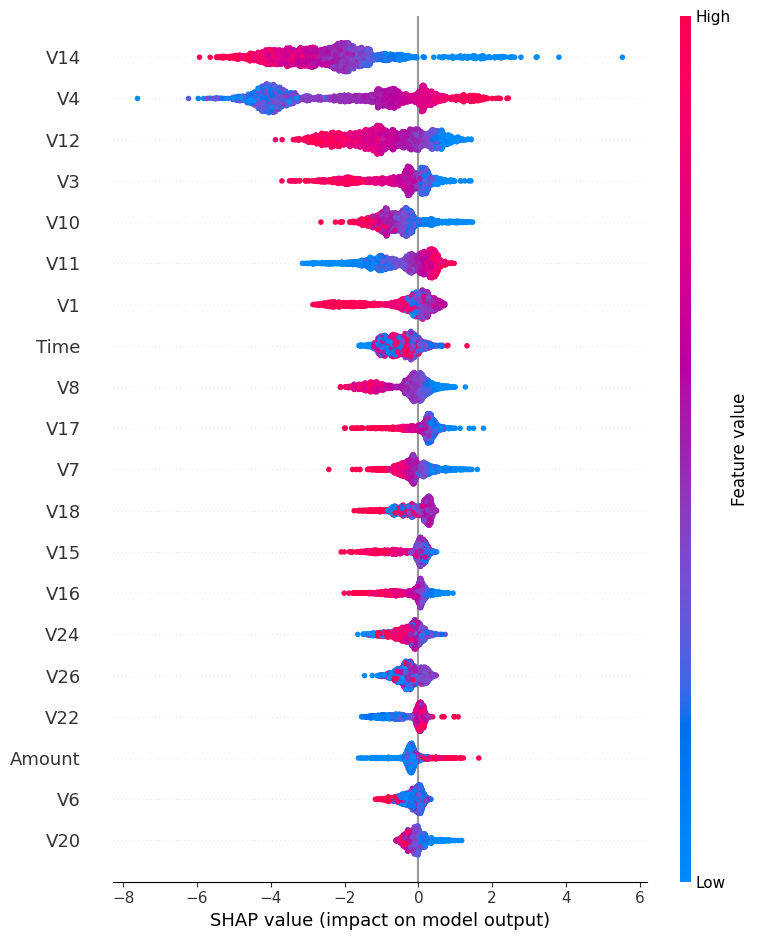

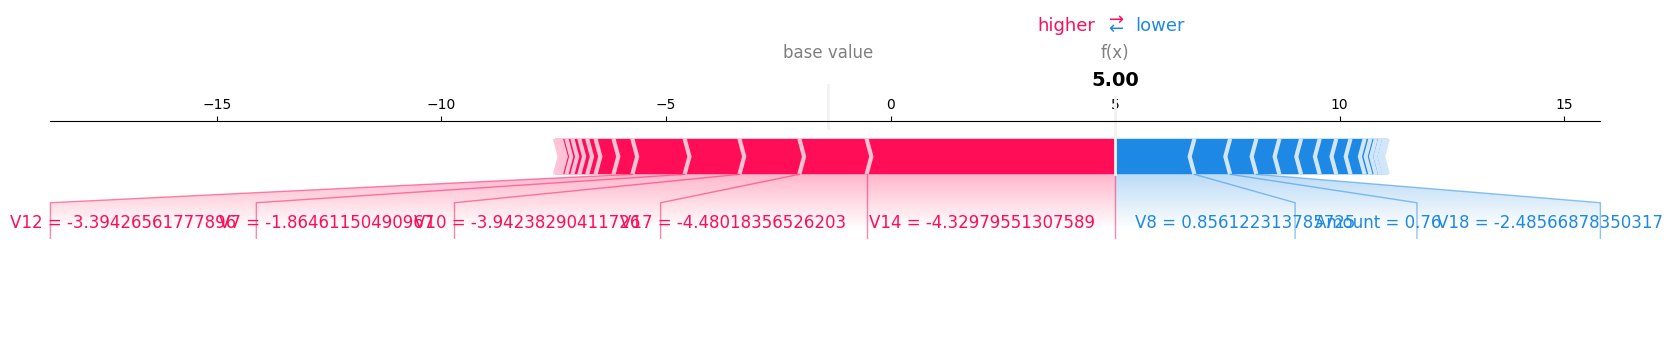

In [17]:
# Use a sample for speed on large datasets
sample_idx = np.random.choice(X_test.index, size=min(2000, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot: which features push predictions toward fraud
shap.summary_plot(shap_values, X_sample, max_display=20)

# Individual prediction explanation (e.g. explain the top predicted fraud case)
top_fraud_idx = np.argsort(-model.predict_proba(X_sample)[:,1])[0]
shap.force_plot(
    explainer.expected_value, shap_values[top_fraud_idx], X_sample.iloc[top_fraud_idx],
    matplotlib=True
)


In [18]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    X_tr_res, y_tr_res = SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)

    m = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                           eval_metric='aucpr', random_state=RANDOM_STATE, n_jobs=-1)
    m.fit(X_tr_res, y_tr_res)
    val_proba = m.predict_proba(X_val)[:,1]
    cv_scores.append(average_precision_score(y_val, val_proba))

print(f"CV PR-AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

CV PR-AUC: 0.8507 ± 0.0254
